# Step 4: Model Testing & Evaluation
**FreshGuard ML Pipeline**

We evaluate beyond accuracy. False alerts cause unnecessary discounts and revenue loss, so **precision on the high-risk class** is critical.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay
)

lr_model = joblib.load('outputs/logistic_regression_model.pkl')
rf_model = joblib.load('outputs/random_forest_model.pkl')

X_test  = pd.read_csv('outputs/X_test.csv')
y_test  = pd.read_csv('outputs/y_test.csv').squeeze()
X_train = pd.read_csv('outputs/X_train.csv')
y_train = pd.read_csv('outputs/y_train.csv').squeeze()

print('Models and test data loaded.')

Models and test data loaded.


In [16]:
lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print('Predictions generated.')

Predictions generated.


## 4.1 Metrics Summary

| Metric | Why it matters |
|---|---|
| Accuracy | Overall correctness |
| Precision (High-Risk) | Avoid unnecessary discounts — false positives cost money |
| Recall (High-Risk) | Catch actual expiry cases before it is too late |
| F1 Score | Balance of precision and recall |
| ROC-AUC | Overall discriminative ability of the model |

In [17]:
def evaluate(name, y_true, y_pred, y_prob):
    print(f'\n=== {name} ===')
    print(f'Accuracy:              {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision (High-Risk): {precision_score(y_true, y_pred):.4f}')
    print(f'Recall    (High-Risk): {recall_score(y_true, y_pred):.4f}')
    print(f'F1 Score  (High-Risk): {f1_score(y_true, y_pred):.4f}')
    print(f'ROC-AUC:               {roc_auc_score(y_true, y_prob):.4f}')
    print()
    print(classification_report(y_true, y_pred,
          target_names=['Sold Before Expiry','Expired Unsold']))

evaluate('Logistic Regression',     y_test, lr_pred, lr_prob)
evaluate('Random Forest (Tuned)',   y_test, rf_pred, rf_prob)


=== Logistic Regression ===
Accuracy:              0.7738
Precision (High-Risk): 0.8399
Recall    (High-Risk): 0.7409
F1 Score  (High-Risk): 0.7873
ROC-AUC:               0.8753

                    precision    recall  f1-score   support

Sold Before Expiry       0.71      0.82      0.76      7805
    Expired Unsold       0.84      0.74      0.79     10136

          accuracy                           0.77     17941
         macro avg       0.77      0.78      0.77     17941
      weighted avg       0.78      0.77      0.77     17941


=== Random Forest (Tuned) ===
Accuracy:              0.9418
Precision (High-Risk): 0.9659
Recall    (High-Risk): 0.9298
F1 Score  (High-Risk): 0.9475
ROC-AUC:               0.9883

                    precision    recall  f1-score   support

Sold Before Expiry       0.91      0.96      0.93      7805
    Expired Unsold       0.97      0.93      0.95     10136

          accuracy                           0.94     17941
         macro avg       0.94    

## 4.2 Confusion Matrices

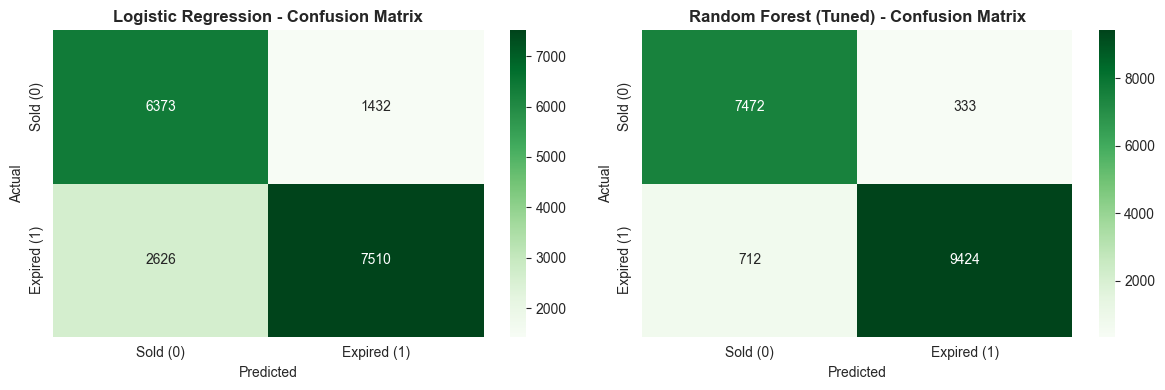

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ['Sold (0)', 'Expired (1)']

for ax, name, pred in zip(axes,
        ['Logistic Regression', 'Random Forest (Tuned)'],
        [lr_pred, rf_pred]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Greens', xticklabels=labels, yticklabels=labels)
    ax.set_title(f'{name} - Confusion Matrix', fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('outputs/confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

## 4.3 ROC Curves

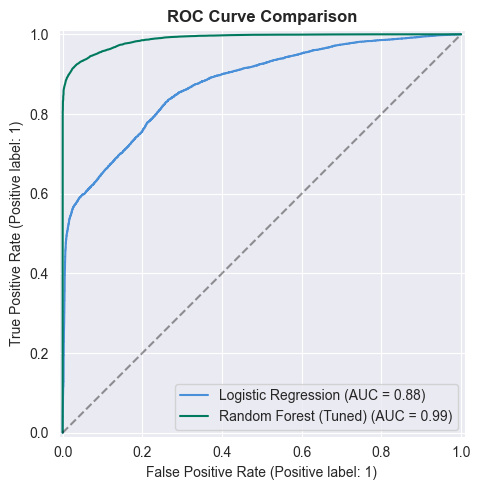

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, lr_prob,
    name='Logistic Regression', ax=ax, color='#4A90D9')
RocCurveDisplay.from_predictions(y_test, rf_prob,
    name='Random Forest (Tuned)', ax=ax, color='#007A5E')
ax.plot([0,1],[0,1], 'k--', alpha=0.4)
ax.set_title('ROC Curve Comparison', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 4.4 Probability Score Distribution

The model outputs a **continuous probability**, not a binary decision.
This is what rules cannot do meaningfully.

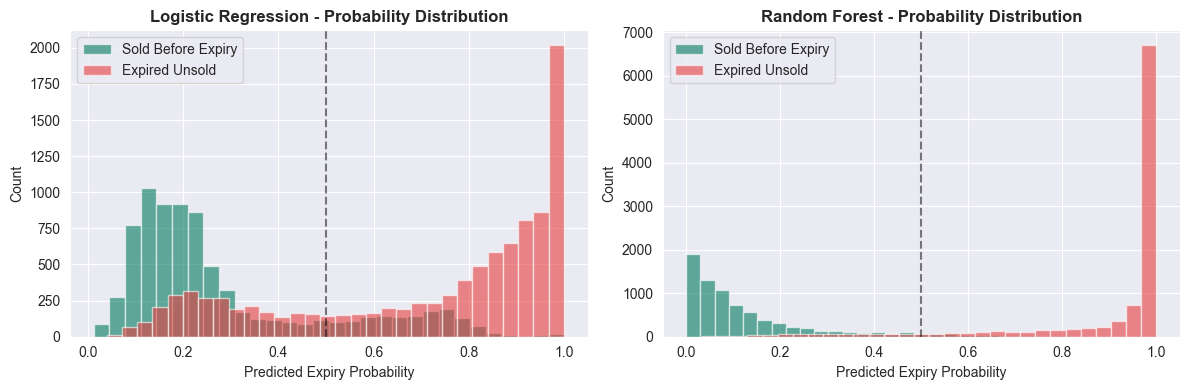

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name, prob in zip(axes,
        ['Logistic Regression', 'Random Forest'],
        [lr_prob, rf_prob]):
    ax.hist(prob[y_test==0], bins=30, alpha=0.6, color='#007A5E', label='Sold Before Expiry')
    ax.hist(prob[y_test==1], bins=30, alpha=0.6, color='#E53E3E', label='Expired Unsold')
    ax.axvline(0.5, color='black', linestyle='--', alpha=0.5)
    ax.set_title(f'{name} - Probability Distribution', fontweight='bold')
    ax.set_xlabel('Predicted Expiry Probability')
    ax.set_ylabel('Count')
    ax.legend()
plt.tight_layout()
plt.savefig('outputs/probability_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

In [21]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest (Tuned)'],
    'Accuracy':           [accuracy_score(y_test, lr_pred),  accuracy_score(y_test, rf_pred)],
    'Precision_HighRisk': [precision_score(y_test, lr_pred), precision_score(y_test, rf_pred)],
    'Recall_HighRisk':    [recall_score(y_test, lr_pred),    recall_score(y_test, rf_pred)],
    'F1_Score':           [f1_score(y_test, lr_pred),        f1_score(y_test, rf_pred)],
    'ROC_AUC':            [roc_auc_score(y_test, lr_prob),   roc_auc_score(y_test, rf_prob)]
}).round(4)
results.to_csv('outputs/model_comparison.csv', index=False)
print('=== Model Comparison ===')
print(results.to_string(index=False))

=== Model Comparison ===
                Model  Accuracy  Precision_HighRisk  Recall_HighRisk  F1_Score  ROC_AUC
  Logistic Regression    0.7738              0.8399           0.7409    0.7873   0.8753
Random Forest (Tuned)    0.9418              0.9659           0.9298    0.9475   0.9883


## Summary

- Used Accuracy, Precision, Recall, F1, ROC-AUC — not just accuracy.
- High precision matters: false alerts cause unnecessary discounts and revenue loss.
- Random Forest outperforms Logistic Regression on non-linear patterns.
- **Key point:** The model outputs a probability score, not a rule-based decision.

**Next: Step5_Prediction_Business_Mapping.ipynb**